# Fit and visualize 3D histogramm based model 
Model described in Skriabine S. et al 2026. The model actually overfits data.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from tqdm import tqdm

from wavelet_utils import loadFilterParamDict
from sophie_model import apply_model, fit_model, smooth_stimulus_signals

Expecting to have:
* Cell database: cells_waven1.cellDB_pickle having records for each neuron 

In [40]:
#jobFolder_str=r"GBM11\g11_0409_zebra"
jobFolder_str=r"GBM11\g11_0409_zebra5"
#jobFolder_str=r"GBM11\g11_0415_zebra5"
#jobFolder_str=r"GBM11\g11_0423_zebra6"
#jobFolder_str=r"GBM11\g11_0508_full"
#jobFolder_str=r"GBM15\g15_0408_zebra"
#jobFolder_str=r"GBM15\g15_0422_zebra3"

In [41]:
# Path definitions
data_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS"

temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

lib_dim="40_26_8_5_4_2"

libpath= Path(temppath) / f'gaborLibrary_{lib_dim}.npy'
paramspath = libpath.with_suffix('.json')   

downsampled_video_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled.npy"

In [42]:
# Load inputs
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(paramspath)

input_pickle= Path(data_path) / "cells_waven1.cellDB_pickle"
df_cells=pd.read_pickle(input_pickle)

df_cells

,cell_id,SeriesID,SNR,R_value,CNN,Accepted,Soma_Xpix,Soma_Ypix,contour,RF_indexes,...,RF_value,Azimuth,Elevation,Angle,Size,Frequency,Angle_fit_ori,Angle_fit_amplitude,Angle_fit_constant,Angle_fit_OSI
cell_id,,,,,,,,,,,,,,,,,,,,,
0,0,g11_0409_zebra5,3.702055,0.846081,0.695202,True,5.318614,10.911077,"[[nan, nan], [4.108625215102572, 15.0], [5.0, ...","[17, 20, 7, 3, 2]",...,0.300386,-50.625,17.307692,2.748894,9.525249,0.05848,2.699422,0.250895,0.045250,0.847202
1,1,g11_0409_zebra5,2.699508,0.868755,0.999747,True,7.631077,33.129955,"[[nan, nan], [8.669051077958464, 36.0], [9.0, ...","[17, 23, 1, 3, 3]",...,0.421140,-50.625,24.230769,0.392699,9.525249,0.10000,0.337913,0.288594,0.040446,0.877079
2,2,g11_0409_zebra5,1.568210,0.402314,0.904663,False,15.634632,26.354231,"[[nan, nan], [19.690770239130163, 30.0], [20.0...","[13, 19, 0, 1, 3]",...,0.269256,-59.625,15.000000,0.000000,4.409334,0.10000,3.111797,0.268416,0.012859,0.954282
3,3,g11_0409_zebra5,1.922118,0.806961,0.981885,True,17.569790,33.833533,"[[nan, nan], [19.832363490075355, 36.0], [20.0...","[9, 21, 7, 4, 0]",...,0.267179,-68.625,19.615385,2.748894,14.000000,0.02000,2.951273,0.024861,0.243881,0.092510
4,4,g11_0409_zebra5,1.249761,0.629703,0.629156,False,34.205115,5.517506,"[[nan, nan], [33.77605088223731, 10.0], [34.0,...","[12, 25, 2, 4, 2]",...,0.168119,-61.875,28.846154,0.785398,14.000000,0.05848,1.023979,0.120947,0.028826,0.807535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249,2249,g11_0409_zebra5,1.561412,0.788473,0.999880,True,338.390643,140.038287,"[[nan, nan], [340.56224472995206, 143.0], [341...","[18, 25, 2, 4, 1]",...,0.245082,-48.375,28.846154,0.785398,14.000000,0.03420,0.882069,0.059852,0.167060,0.263767
2250,2250,g11_0409_zebra5,1.986334,0.834088,0.999340,True,128.793998,181.354349,"[[nan, nan], [131.0325258846103, 184.0], [132....","[23, 0, 3, 3, 3]",...,0.170346,-37.125,-28.846154,1.178097,9.525249,0.10000,1.304721,0.120544,0.037868,0.760954
2251,2251,g11_0409_zebra5,2.417578,0.810271,0.890795,True,347.983284,254.186628,"[[nan, nan], [350.61445700363845, 258.0], [350...","[27, 23, 3, 4, 0]",...,0.281719,-28.125,24.230769,1.178097,14.000000,0.02000,1.366824,0.040068,0.245626,0.140249


In [43]:
resolution = 2.14 # um/px

In [44]:
#collecting inputs        
n_neurons = len(df_cells)
n_timepoints = len(df_cells.iloc[0]['WL_transient_phase']) # assume each entry has the same length
n_trials=df_cells.iloc[0]['Cell_activity'].shape[0]

phi_all  = np.empty((n_neurons, n_timepoints), dtype=float)
dphi_all = np.empty((n_neurons, n_timepoints), dtype=float)
rho_all  = np.empty((n_neurons, n_timepoints), dtype=float)
spks_all = np.empty((n_neurons, n_trials, n_timepoints), dtype=float)

respcorr = np.empty((n_neurons), dtype=float)

for i, (_idx, row) in enumerate(df_cells.iterrows()):
        
    rho=np.sqrt(row['WL_transient_squared'])  
    phi=(row['WL_transient_phase'])
    dphi = np.diff(np.unwrap(phi), prepend=0)
    
    #dphi[abs(dphi) >= 3] = np.nan
    #nans, x = nan_helper(dphi)
    #dphi[nans] = np.interp(x(nans), x(~nans), dphi[~nans])
    
    spks=row['Cell_activity']
    
    rho_all[i]  = rho
    phi_all[i]  = phi
    dphi_all[i] = dphi
    spks_all[i] = spks
    
    respcorr[i] = row["Repeatability"]
    

             

In [45]:
average_FWHM_samples = 9 #smoothing

hanning_window=5

train_test=True #whether to split data in train and test set, if False use all data for training and no test evaluation
train_split=0.9 #plit ratio in time if train_test
if n_trials <= 2:
    train_test=False
    print("Not enough trials for test evaluation")


if train_test:
    train_split_index=int(rho_all.shape[1]*train_split)
else:
    train_split_index=rho_all.shape[1]
    
if train_test:
    if n_trials == 3:
        train_trials=[0,1]
    elif n_trials == 4:
        train_trials=[0,1,2]
    else:
        train_trials=range(0,n_trials, 2)
else:
    train_trials=range(0,n_trials)
test_trials=[i for i in range(n_trials) if i not in train_trials]
print(f"Train trials: {list(train_trials)}, Test trials: {list(test_trials)}")
print(f"Train split at {train_split_index/rho_all.shape[1]*100:.1f}% of timepoints, test split at {((1-train_split_index/rho_all.shape[1])*100):.1f}% of timepoints")

r_train = np.ones((n_neurons), dtype=float)*np.nan  #correlation of prediction and truth on the training data and: Training performance
r_repeat_gen = np.ones((n_neurons), dtype=float)*np.nan  #correlation of prediction on unseen trials: Across-trial predictability
r_time_gen = np.ones((n_neurons), dtype=float)*np.nan #correlation of prediction and truth on unseen stimuli at the end of the trials: Out-of-time generalization
Zs=[]

largest_respcorr_indices = np.argsort(respcorr)[-20:]

torun=range(n_neurons)
#torun=largest_respcorr_indices #carfully!

for i in tqdm(torun):
    
        #plot
        rho = rho_all[i]
        phi = phi_all[i]
        dphi = dphi_all[i]
        spks = spks_all[i]
        
        rho_train=rho[:train_split_index]
        phi_train=phi[:train_split_index]
        dphi_train=dphi[:train_split_index]
        
        rho_test=rho[train_split_index:]
        phi_test=phi[train_split_index:]
        dphi_test=dphi[train_split_index:]

        spks_train=np.mean(spks[train_trials, :train_split_index], axis=0)
        
        interpolator, Z, rho_centers, phi_centers, dphi_centers=fit_model(rho_train, phi_train, dphi_train, spks_train, hanning_window=hanning_window, smooth_stim_FWHM_samples=average_FWHM_samples)
        Zs.append(Z)
        
        pred_spks_train=apply_model(interpolator, rho_train, phi_train, dphi_train, smooth_stim_FWHM_samples=average_FWHM_samples)
        r_train[i] = np.corrcoef(spks_train, pred_spks_train)[0, 1]
        
        if train_test:
            spks_test_trials=np.mean(spks[test_trials, :train_split_index], axis=0)
            r_repeat_gen[i] = np.corrcoef(spks_test_trials, pred_spks_train)[0, 1]

            spks_test_time=np.mean(spks[train_trials, train_split_index:], axis=0)
            pred_spks_test_time=apply_model(interpolator, rho_test, phi_test, dphi_test, smooth_stim_FWHM_samples=average_FWHM_samples)
            r_time_gen[i] = np.corrcoef(spks_test_time, pred_spks_test_time)[0, 1]            
        
        
#statistics on largest 20 respcorr values
print(f"Repeatibility (respcorr) (mean of largest 20 neurons): {np.mean(respcorr[largest_respcorr_indices]):.3f}")
print(f"Training performance (correlation of prediction and truth) (mean of largest respcorr 20 neurons): {np.mean(r_train[largest_respcorr_indices]):.3f}")
if train_test:
    print(f"Across-trial predictability (correlation of prediction and truth on test trials) (mean of largest respcorr 20 neurons): {np.mean(r_repeat_gen[largest_respcorr_indices]):.3f}")
    print(f"Out-of-time generalization (correlation of prediction and truth on unseen data) (mean of largest respcorr 20 neurons): {np.mean(r_time_gen[largest_respcorr_indices]):.3f}")


Train trials: [0, 2, 4], Test trials: [1, 3]
Train split at 90.0% of timepoints, test split at 10.0% of timepoints


100%|██████████| 2254/2254 [00:33<00:00, 66.96it/s]

Repeatibility (respcorr) (mean of largest 20 neurons): 0.735
Training performance (correlation of prediction and truth) (mean of largest respcorr 20 neurons): 0.615
Across-trial predictability (correlation of prediction and truth on test trials) (mean of largest respcorr 20 neurons): 0.529
Out-of-time generalization (correlation of prediction and truth on unseen data) (mean of largest respcorr 20 neurons): 0.299


In [46]:
print(f"Mean correlation of respcorr>0.2 neurons: {np.mean(r_train[respcorr>0.2])}")

Mean correlation of respcorr>0.2 neurons: 0.5153071392582166


In [47]:
 # plotting temporal curves
 %matplotlib widget
 def plot_model(rho_original, phi_original, dphi_original, spks, pred, title="", smooth_stim_FWHM_samples=0):
   
    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    
    x=np.argmax(spks)
    print(x)
    
    rho, phi, dphi = smooth_stimulus_signals(rho_original, phi_original, dphi_original, smooth_stim_FWHM_samples)
    
    signals = [rho, phi, dphi]
    signals_original = [rho_original, phi_original, dphi_original]
    names = ["rho", "phi", "dphi"]

    for ax, sig, sig_o, name in zip(axes, signals, signals_original, names):
        # left axis: actual vs predicted
        ax.plot(spks, label="actual", color="black")
        ax.plot(pred, label="predicted", color="red", alpha=0.7)
        ax.set_ylabel("spks / pred")

        # right axis: feature
        ax_r = ax.twinx()
        ax_r.plot(sig_o, label=name, color="green", alpha=0.2)
        ax_r.plot(sig, label=name, color="blue", alpha=0.4)
        ax_r.set_ylabel(name)

        ax.set_title(name)

    window = 400
    axes[0].set_xlim(x-window, x+window)
    # legend only once (cleaner)
    axes[0].legend(loc="upper left")
    fig.suptitle(title)
    plt.xlabel("time")
    plt.tight_layout()
    plt.show()

c:\Users\KatonaGergely\anaconda3\envs\caiman14\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\KatonaGergely\anaconda3\envs\caiman14\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


2215


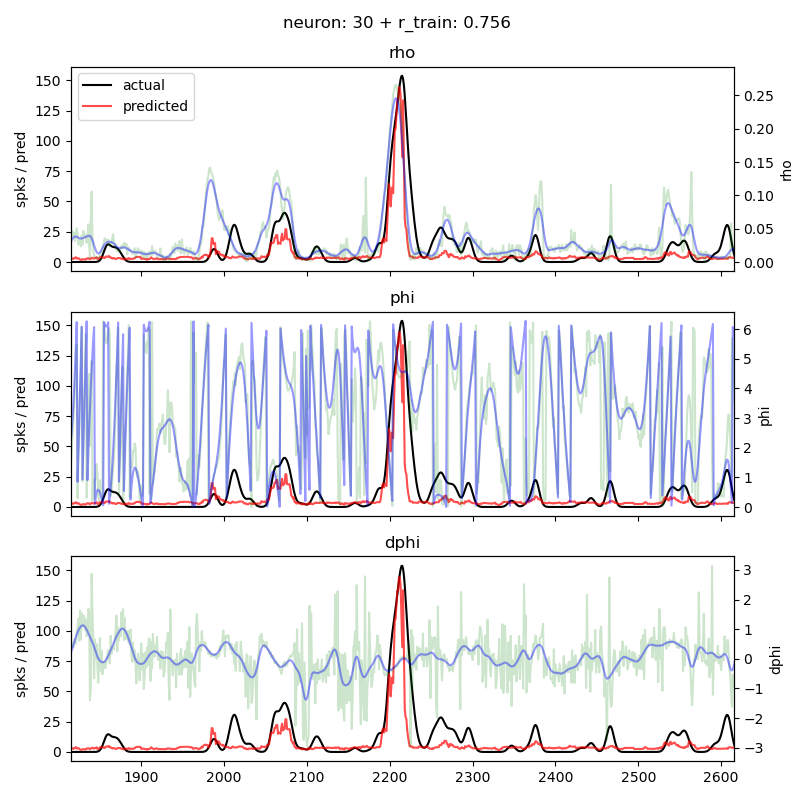

In [48]:
# Plot fitting curves
testneuron=30
#testneuron=456
#testneuron=1813

rho = rho_all[testneuron]
phi = phi_all[testneuron]
dphi = dphi_all[testneuron]
spks = spks_all[testneuron]

rho_train=rho[:train_split_index]
phi_train=phi[:train_split_index]
dphi_train=dphi[:train_split_index]
spks_train=np.mean(spks[train_trials,:train_split_index], axis=0)

rho_test=rho[train_split_index:]
phi_test=phi[train_split_index:]
dphi_test=dphi[train_split_index:]
spks_test=np.mean(spks[train_split_index:], axis=0)
         
interpolator, Z, rho_centers, phi_centers, dphi_centers=fit_model(rho_train, phi_train, dphi_train, spks_train, hanning_window=hanning_window, smooth_stim_FWHM_samples=average_FWHM_samples)

pred_spks_test=apply_model(interpolator, rho_test, phi_test, dphi_test, smooth_stim_FWHM_samples=average_FWHM_samples)
pred_spks_train=apply_model(interpolator, rho_train, phi_train, dphi_train, smooth_stim_FWHM_samples=average_FWHM_samples)

#plot_model(rho_test, phi_test, dphi_test, spks_test, pred_spks_test, title=f"neuron: {testneuron} + r_train: {r_train[testneuron]:.3f} ", smooth_stim_FWHM_samples=average_FWHM_samples)
plot_model(rho_train, phi_train, dphi_train, spks_train, pred_spks_train, title=f"neuron: {testneuron} + r_train: {r_train[testneuron]:.3f} ", smooth_stim_FWHM_samples=average_FWHM_samples)


(np.int64(19), np.int64(0), np.int64(4))
464.63448546851623


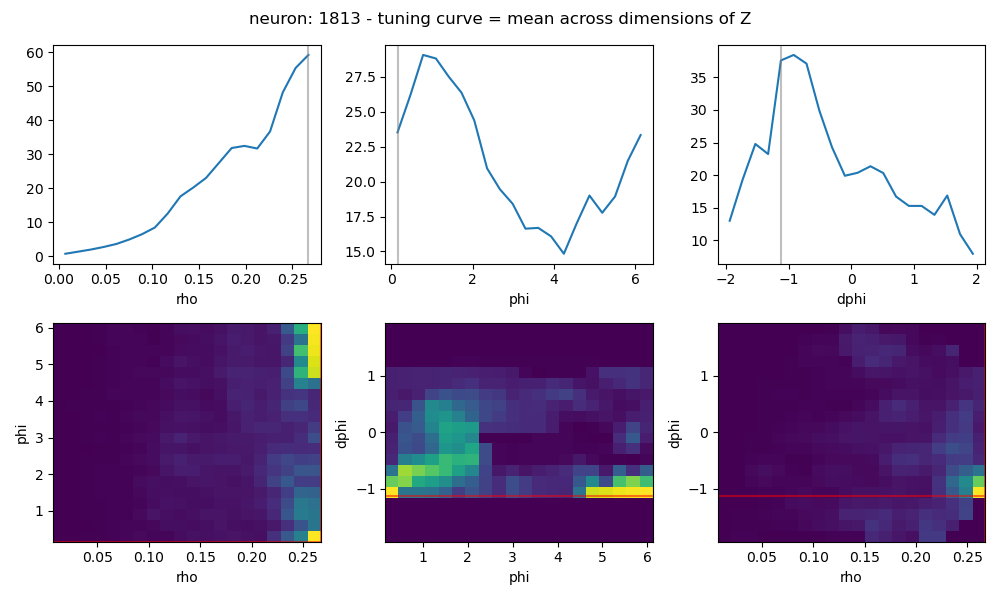

In [49]:
fig, ax=plt.subplots(2,3, figsize=(10,6))

ni=1813

Z=Zs[ni]
Z[np.isnan(Z)]=0
max_idx=np.unravel_index(np.argmax(Z), Z.shape)
print(max_idx)
print(np.nanmax(Z))
#ax[0,0].plot(rho_centers, Z[:,max_idx[1],max_idx[2]])
ax[0,0].plot(rho_centers, np.nanmean(Z, axis=(1,2)))
ax[0,0].set_xlabel("rho")
ax[0,0].axvline(rho_centers[max_idx[0]], color="gray", alpha=0.5)
#ax[0,1].plot(phi_centers, Z[max_idx[0],:,max_idx[2]])
ax[0,1].plot(phi_centers, np.nanmean(Z, axis=(0,2)))
ax[0,1].set_xlabel("phi")
ax[0,1].axvline(phi_centers[max_idx[1]], color="gray", alpha=0.5)
#ax[0,2].plot(dphi_centers, Z[max_idx[0],max_idx[1],:])
ax[0,2].plot(dphi_centers, np.nanmean(Z, axis=(0,1)))
ax[0,2].set_xlabel("dphi")
ax[0,2].axvline(dphi_centers[max_idx[2]], color="gray", alpha=0.5)

ax[1,0].imshow(Z[:,:,max_idx[2]].T, aspect="auto", origin="lower", extent=[rho_centers[0], rho_centers[-1], phi_centers[0], phi_centers[-1]])
ax[1,0].set_xlabel("rho")
ax[1,0].set_ylabel("phi")
ax[1,0].axvline(rho_centers[max_idx[0]], color="red", alpha=0.5)
ax[1,0].axhline(phi_centers[max_idx[1]], color="red", alpha=0.5)
ax[1,1].imshow(Z[max_idx[0],:,:].T, aspect="auto", origin="lower", extent=[phi_centers[0], phi_centers[-1], dphi_centers[0], dphi_centers[-1]])
ax[1,1].set_xlabel("phi")
ax[1,1].set_ylabel("dphi")
ax[1,1].axvline(phi_centers[max_idx[1]], color="red", alpha=0.5)
ax[1,1].axhline(dphi_centers[max_idx[2]], color="red", alpha=0.5)
ax[1,2].imshow(Z[:,max_idx[1],:].T, aspect="auto", origin="lower", extent=[rho_centers[0], rho_centers[-1], dphi_centers[0], dphi_centers[-1]])
ax[1,2].set_xlabel("rho")
ax[1,2].set_ylabel("dphi")
ax[1,2].axvline(rho_centers[max_idx[0]], color="red", alpha=0.5)
ax[1,2].axhline(dphi_centers[max_idx[2]], color="red", alpha=0.5)

plt.suptitle(f"neuron: {ni} - tuning curve = mean across dimensions of Z")
plt.tight_layout()
plt.show()

In [50]:
dphi_centers

array([-1.93640285, -1.73257097, -1.52873909, -1.32490721, -1.12107533,
       -0.91724345, -0.71341157, -0.5095797 , -0.30574782, -0.10191594,
        0.10191594,  0.30574782,  0.5095797 ,  0.71341157,  0.91724345,
        1.12107533,  1.32490721,  1.52873909,  1.73257097,  1.93640285])

In [51]:
df = pd.DataFrame({'respcorr': respcorr, 'r_train': r_train, 'r_repeat_gen': r_repeat_gen, 'r_time_gen': r_time_gen})
df.to_csv(Path(data_path) / 'respcorr_max_values_6.csv', index=False)

In [52]:
#save results into cell database
input_pickle_path= Path(data_path) / "cells_waven1.cellDB_pickle"
if input_pickle_path.exists():
    df_cells=pd.read_pickle(open(input_pickle_path,"rb"))
else:
    df_cells = pd.DataFrame()
    for _idx in range(n_neurons): #handling only good components
            record={}
            record['cell_id'] = _idx
            record['SeriesID'] = 'unknown'
            df_cells = pd.concat([df_cells, pd.DataFrame([record])], ignore_index=True)

df_cells = df_cells.set_index("cell_id", drop=False)

df_cells["tun_rho"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_phi"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_dphi"] = pd.Series([None] * len(df_cells), dtype="object")


for _idx in tqdm(range(n_neurons)):
    df_cells.loc[_idx,'r_train'] = r_train[_idx]
    df_cells.loc[_idx,'r_repeat_gen'] = r_repeat_gen[_idx]
    df_cells.loc[_idx,'r_time_gen'] = r_time_gen[_idx]

    Z = Zs[_idx]
    tuning_rho=np.mean(Z, axis=(1,2))
    tuning_phi=np.mean(Z, axis=(0,2))
    tuning_dphi=np.mean(Z, axis=(1,2))
    
    df_cells.at[_idx, 'tun_rho'] = tuning_rho
    df_cells.at[_idx, 'tun_phi'] = tuning_phi
    df_cells.at[_idx, 'tun_dphi'] = tuning_dphi
    
    max_idx=np.unravel_index(np.argmax(Z), Z.shape)
    df_cells.loc[_idx, 'Rho_idx'] = rho_centers[max_idx[0]]
    df_cells.loc[_idx, 'Phi_idx'] = phi_centers[max_idx[1]]
    df_cells.loc[_idx, 'DPhi_idx'] = dphi_centers[max_idx[2]]

    df_cells.loc[_idx, 'Rho_tun'] = rho_centers[np.argmax(tuning_rho)]
    df_cells.loc[_idx, 'Phi_tun'] = phi_centers[np.argmax(tuning_phi)]
    df_cells.loc[_idx, 'DPhi_tun'] = dphi_centers[np.argmax(tuning_dphi)]

picles_path=Path(data_path) / "cells_waven2.cellDB_pickle"
df_cells.to_pickle(picles_path)

# Saving cell database to xls file. Omitting complicated data
df_cells.drop(columns=['WL_transient_squared', 'WL_transient_phase', 'Cell_activity', 'contour', 'tun_xs', 'tun_ys', 'tun_angles', 'tun_sizes', 'tun_freqs', 'tun_rho', 'tun_phi', 'tun_dphi'], inplace=True, errors='ignore')
df_cells.to_excel(Path(data_path) / "cells_waven2.xlsx", index=False)

print(f"Saved cell database to {picles_path}")



100%|██████████| 2254/2254 [00:01<00:00, 1573.40it/s]


Saved cell database to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\cells_waven2.cellDB_pickle
